<a href="https://colab.research.google.com/github/seeker91/modeling-tasks/blob/main/City_of_Regina_Parking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [ ]:
files = ["/content/sample_data/jan-mar.xls", "/content/sample_data/apr-jun.xls",
        "/content/sample_data/jul-sep.xls", "/content/sample_data/oct-dec.xls"]

dfs = [pd.read_excel(f, engine = "xlrd") for f in files]

df = pd.concat(dfs, ignore_index = True)

In [ ]:
df.head()

,VIOLATION_DATETIME,VIOL_LOC,INF_CD,INF_DESCR
0,31/03/2025 21:28:00,IN FRONT OF 5240 CANUCK CRES,354A,Park a vehicle on a sidewalk or a portion ther...
1,31/03/2025 21:27:00,WEST SIDE 2100 TORONTO ST,361A,stop a vehicle where prohibited
2,31/03/2025 21:14:00,IN FRONT OF 5225 MITCHINSON WAY,321D,Park a vehicle at the curb other than in the d...
3,31/03/2025 20:39:00,OPPOSITE 14 RYAN RD,361C,Park or stop a vehicle in a traffic lane of an...
4,31/03/2025 20:19:00,IN FRONT OF 158 DAVIDSON CRES,361E,stopped within 10 metres of a street intersection


In [ ]:
df.to_csv('combined_files.csv', index=False)

In [ ]:
df.shape

(56223, 4)

In [ ]:
df.isnull().sum()

,0
VIOLATION_DATETIME,0
VIOL_LOC,0
INF_CD,0
INF_DESCR,0


In [ ]:
df.duplicated().sum()

np.int64(182)

In [ ]:
df.head()

,VIOLATION_DATETIME,VIOL_LOC,INF_CD,INF_DESCR
0,31/03/2025 21:28:00,IN FRONT OF 5240 CANUCK CRES,354A,Park a vehicle on a sidewalk or a portion ther...
1,31/03/2025 21:27:00,WEST SIDE 2100 TORONTO ST,361A,stop a vehicle where prohibited
2,31/03/2025 21:14:00,IN FRONT OF 5225 MITCHINSON WAY,321D,Park a vehicle at the curb other than in the d...
3,31/03/2025 20:39:00,OPPOSITE 14 RYAN RD,361C,Park or stop a vehicle in a traffic lane of an...
4,31/03/2025 20:19:00,IN FRONT OF 158 DAVIDSON CRES,361E,stopped within 10 metres of a street intersection


In [ ]:
df["INF_CD"].nunique()

52

In [ ]:
total = len(df)
total

56223

In [ ]:
import datetime as dt

df["VIOLATION_DATETIME"] = pd.to_datetime(df["VIOLATION_DATETIME"])
df["month"] = df['VIOLATION_DATETIME'].dt.month
df["month_name"] = df['VIOLATION_DATETIME'].dt.month_name()
df["day_name"] = df['VIOLATION_DATETIME'].dt.day_name()
df["dow_no"] = df['VIOLATION_DATETIME'].dt.dayofweek
df["weekend"] = df["dow_no"] > 4
df["hour"] = df['VIOLATION_DATETIME'].dt.hour

In [ ]:
df["paid_metered"] = df["INF_DESCR"].str.contains("metered parking | paid parking", case = False, na = False)

In [ ]:
paid_metered_count = len(df[df["paid_metered"] == True])
paid_metered_count_share = paid_metered_count / total
print(f"Paid metered %: {round(paid_metered_count_share * 100, 2)}%\n Count: {paid_metered_count}")

Paid metered %: 26.77%
 Count: 15051


In [ ]:
df.head()

,VIOLATION_DATETIME,VIOL_LOC,INF_CD,INF_DESCR,month,month_name,day_name,dow_no,weekend,hour,paid_metered
0,2025-03-31 21:28:00,IN FRONT OF 5240 CANUCK CRES,354A,Park a vehicle on a sidewalk or a portion ther...,3,March,Monday,0,False,21,False
1,2025-03-31 21:27:00,WEST SIDE 2100 TORONTO ST,361A,stop a vehicle where prohibited,3,March,Monday,0,False,21,False
2,2025-03-31 21:14:00,IN FRONT OF 5225 MITCHINSON WAY,321D,Park a vehicle at the curb other than in the d...,3,March,Monday,0,False,21,False
3,2025-03-31 20:39:00,OPPOSITE 14 RYAN RD,361C,Park or stop a vehicle in a traffic lane of an...,3,March,Monday,0,False,20,False
4,2025-03-31 20:19:00,IN FRONT OF 158 DAVIDSON CRES,361E,stopped within 10 metres of a street intersection,3,March,Monday,0,False,20,False


***Monthly Ticket Analysis***

In [ ]:
monthly = df.groupby(["month", "month_name"]).size().reset_index(name = "tickets").sort_values("month")

In [ ]:
df["date"] = df["VIOLATION_DATETIME"].dt.date

In [ ]:
days_of_month = df[["date", "month"]].drop_duplicates().groupby("month").size().reset_index(name="observed_days")

In [ ]:
monthly.head()

,month,month_name,tickets
0,1,January,3482
1,2,February,2654
2,3,March,4188
3,4,April,4315
4,5,May,4656


In [ ]:
monthly = monthly.merge(days_of_month, on = "month")
monthly.head()

,month,month_name,tickets,observed_days
0,1,January,3482,30
1,2,February,2654,27
2,3,March,4188,31
3,4,April,4315,27
4,5,May,4656,30


In [ ]:
monthly["ticket_per_day"] = round((monthly["tickets"] / monthly['observed_days']), 2)
monthly["ticket_share"] = round((monthly["tickets"] / total) * 100, 2)
monthly.head()

,month,month_name,tickets,observed_days,ticket_per_day,ticket_share
0,1,January,3482,30,116.07,6.19
1,2,February,2654,27,98.30,4.72
2,3,March,4188,31,135.10,7.45
3,4,April,4315,27,159.81,7.67
4,5,May,4656,30,155.20,8.28


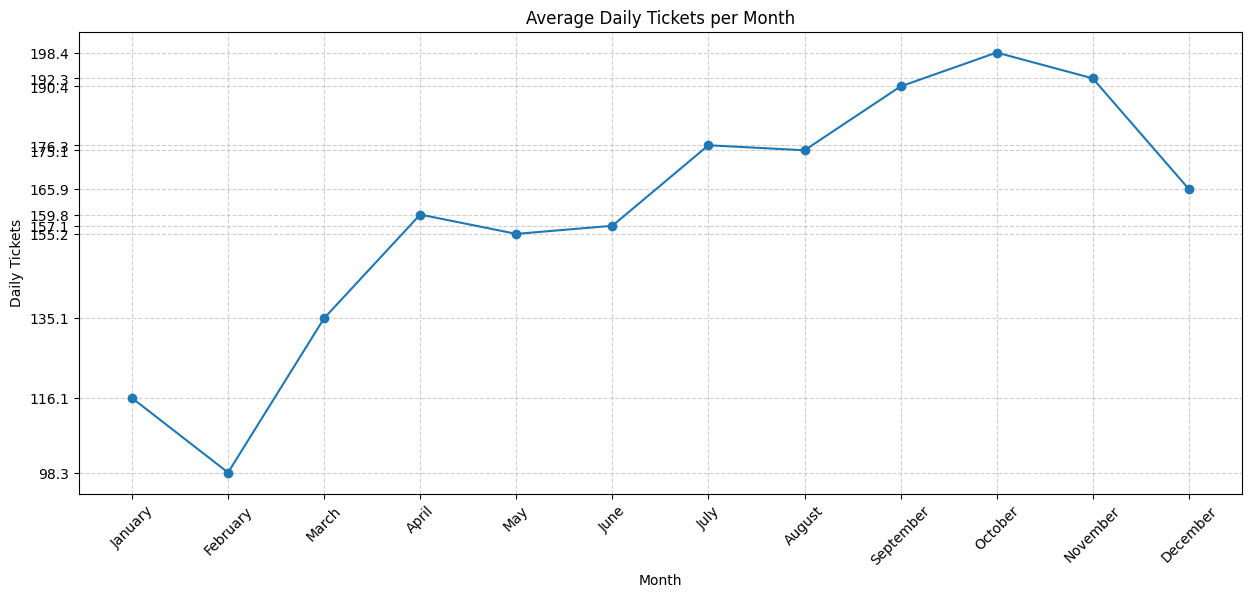

In [ ]:
plt.figure(figsize = (15, 6))
x = monthly["month_name"]
y = monthly["ticket_per_day"]
plt.plot(x, y, "-", marker = "o")
plt.xlabel("Month")
plt.ylabel("Daily Tickets")
plt.title("Average Daily Tickets per Month")
plt.xticks(rotation = 45)
plt.xticks(x)
plt.yticks(y)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

***Daily Ticket Analysis***

In [ ]:
df.head()

,VIOLATION_DATETIME,VIOL_LOC,INF_CD,INF_DESCR,month,month_name,day_name,dow_no,weekend,hour,paid_metered,date
0,2025-03-31 21:28:00,IN FRONT OF 5240 CANUCK CRES,354A,Park a vehicle on a sidewalk or a portion ther...,3,March,Monday,0,False,21,False,2025-03-31
1,2025-03-31 21:27:00,WEST SIDE 2100 TORONTO ST,361A,stop a vehicle where prohibited,3,March,Monday,0,False,21,False,2025-03-31
2,2025-03-31 21:14:00,IN FRONT OF 5225 MITCHINSON WAY,321D,Park a vehicle at the curb other than in the d...,3,March,Monday,0,False,21,False,2025-03-31
3,2025-03-31 20:39:00,OPPOSITE 14 RYAN RD,361C,Park or stop a vehicle in a traffic lane of an...,3,March,Monday,0,False,20,False,2025-03-31
4,2025-03-31 20:19:00,IN FRONT OF 158 DAVIDSON CRES,361E,stopped within 10 metres of a street intersection,3,March,Monday,0,False,20,False,2025-03-31


In [ ]:
days_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
days = df.groupby("day_name").size().reindex(days_order).reset_index(name = "tickets")


In [ ]:
observed_days = df[["date","day_name"]].drop_duplicates().groupby("day_name").size().reindex(days_order).reset_index(name = "days_count")
observed_days

,day_name,days_count
0,Monday,46
1,Tuesday,49
2,Wednesday,52
3,Thursday,51
4,Friday,50
5,Saturday,52
6,Sunday,51


In [ ]:
days = days.merge(observed_days, on = "day_name")
days.head()

,day_name,tickets,days_count
0,Monday,8367,46
1,Tuesday,10211,49
2,Wednesday,10492,52
3,Thursday,10853,51
4,Friday,10641,50


In [ ]:
days["average_per_day"] = round((days["tickets"] / days["days_count"]), 2)
days["day_share"] = round((days["tickets"] / total) * 100, 2)
days.head()

,day_name,tickets,days_count,average_per_day,day_share
0,Monday,8367,46,181.89,14.88
1,Tuesday,10211,49,208.39,18.16
2,Wednesday,10492,52,201.77,18.66
3,Thursday,10853,51,212.80,19.30
4,Friday,10641,50,212.82,18.93


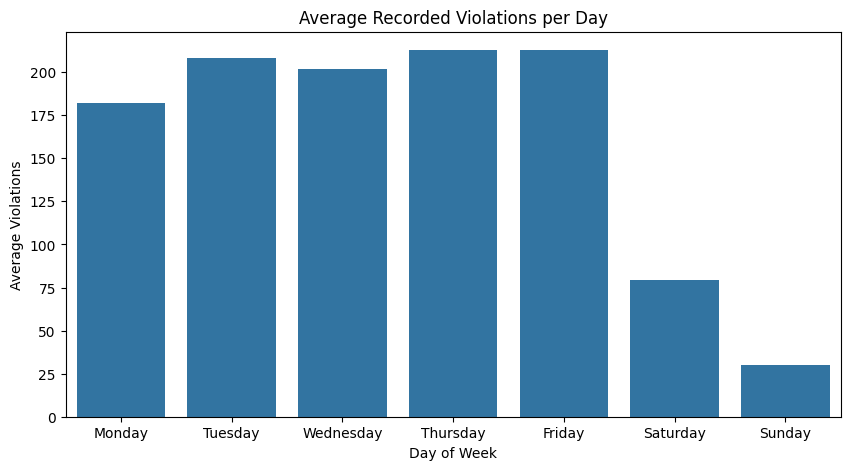

In [ ]:
plt.figure(figsize = (10, 5))
sns.barplot(x = "day_name", y = "average_per_day", data = days)
plt.title("Average Recorded Violations per Day")
plt.xlabel("Day of Week")
plt.ylabel("Average Violations")
plt.show()

***Hour-based Violations***

In [ ]:
hour = df.groupby("hour").size().reindex(range(24), fill_value = "0").reset_index(name = "tickets")
hour['tickets'] = hour['tickets'].astype(int)
hour["average_hour"] = round((hour["tickets"] / total), 2)
hour.head(10)

,hour,tickets,average_hour
0,0,0,0.00
1,1,0,0.00
2,2,0,0.00
3,3,0,0.00
4,4,4,0.00
5,5,243,0.00
6,6,487,0.01
7,7,515,0.01
8,8,1184,0.02
9,9,3504,0.06


In [ ]:
hour[(hour["hour"] >= 9) & (hour["hour"] < 18)]["tickets"].sum() / total

np.float64(0.8405634704658236)

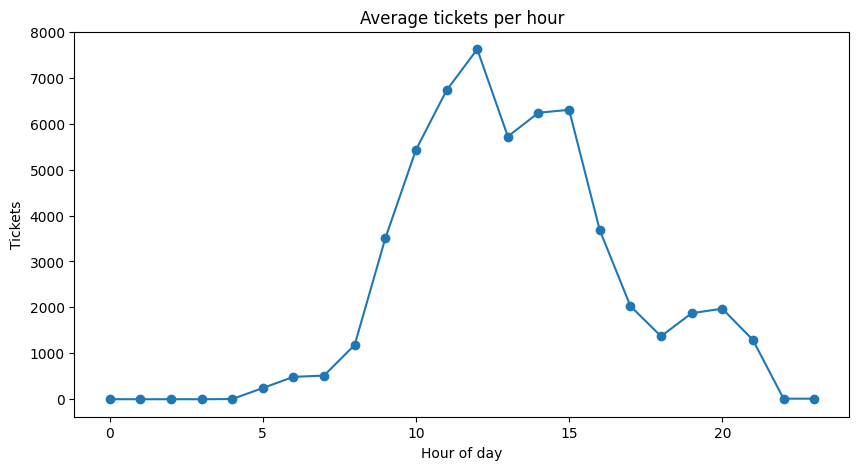

In [ ]:
plt.figure(figsize = (10, 5))
plt.plot(hour["hour"], hour["tickets"], "-", marker = "o")
plt.title("Average tickets per hour")
plt.xlabel("Hour of day")
plt.ylabel("Tickets")
plt.show()

<Axes: >

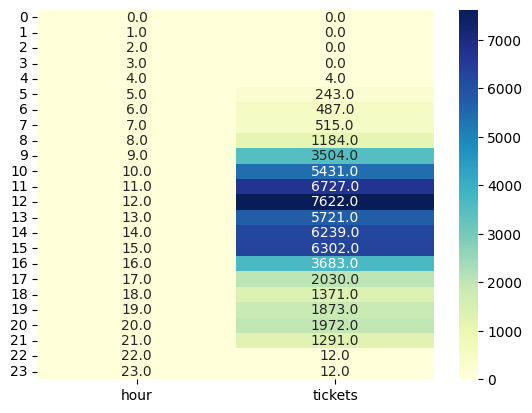

In [ ]:
sns.heatmap(hour[["hour", "tickets"]], annot = True, cmap = "YlGnBu", fmt = ".1f")

***Violation Locations Share***

In [ ]:
locations = df.groupby("VIOL_LOC").size().reset_index(name = "tickets")
locations["location_share"] = round((locations["tickets"] / total) * 100, 2)
locations.sort_values(by = "location_share", ascending = False).head(10)

,VIOL_LOC,tickets,location_share
9719,WEST SIDE 1900 SCARTH ST,1208,2.15
1334,EAST SIDE 1700 HAMILTON ST,764,1.36
9674,WEST SIDE 1800 HAMILTON ST,701,1.25
1362,EAST SIDE 1800 HAMILTON ST,676,1.20
9648,WEST SIDE 1700 HAMILTON ST,632,1.12
1363,EAST SIDE 1800 LORNE ST,605,1.08
9672,WEST SIDE 1800 CORNWALL ST,562,1.00
9705,WEST SIDE 1900 HAMILTON ST,541,0.96
9587,WEST SIDE 1400 WASCANA ST,465,0.83
1276,EAST SIDE 1400 WASCANA ST,432,0.77


In [ ]:
print("Scarth Street violations:", locations[locations["VIOL_LOC"].str.contains("SCARTH ST", case = False, na = False)]["tickets"].sum())
print("Hamilton Street violations:", locations[locations["VIOL_LOC"].str.contains("HAMILTON ST", case = False, na = False)]["tickets"].sum())
print("Lorne Street violations:", locations[locations["VIOL_LOC"].str.contains("LORNE ST", case = False, na = False)]["tickets"].sum())
print("Cornwall Street violations:", locations[locations["VIOL_LOC"].str.contains("CORNWALL ST", case = False, na = False)]["tickets"].sum())
print("Wascana Street violations:", locations[locations["VIOL_LOC"].str.contains("WASCANA ST", case = False, na = False)]["tickets"].sum())

Scarth Street violations: 2432
Hamilton Street violations: 4702
Lorne Street violations: 1885
Cornwall Street violations: 1701
Wascana Street violations: 1138


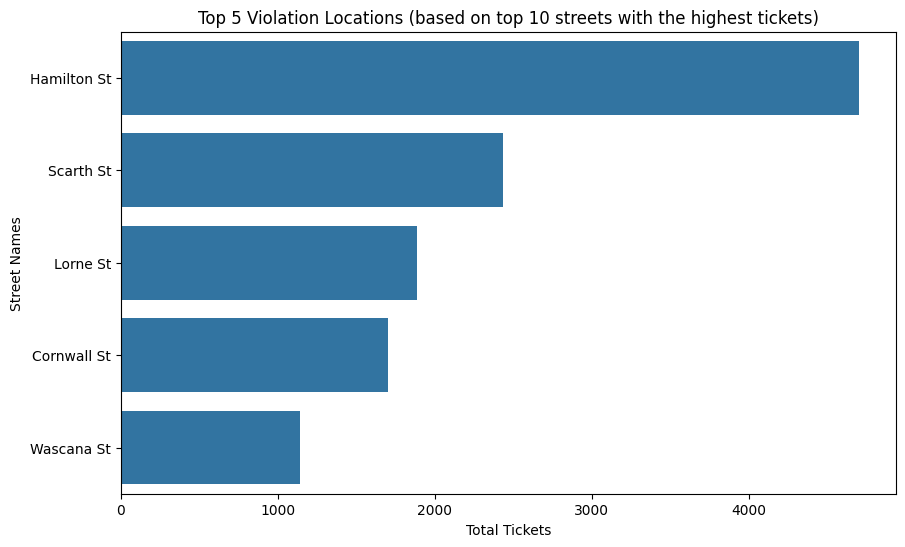

In [ ]:
#Dataframe for the top 10 streets with the highest tickets

plt.figure(figsize = (10, 6))
scarth = locations[locations["VIOL_LOC"].str.contains("SCARTH ST", case = False, na = False)]["tickets"].sum()
hamilton = locations[locations["VIOL_LOC"].str.contains("HAMILTON ST", case = False, na = False)]["tickets"].sum()
lorne = locations[locations["VIOL_LOC"].str.contains("LORNE ST", case = False, na = False)]["tickets"].sum()
cornwall = locations[locations["VIOL_LOC"].str.contains("CORNWALL ST", case = False, na = False)]["tickets"].sum()
wascana = locations[locations["VIOL_LOC"].str.contains("WASCANA ST", case = False, na = False)]["tickets"].sum()

street_names = ["Scarth St", "Hamilton St", "Lorne St", "Cornwall St", "Wascana St"]
df_street = pd.DataFrame({"Street": street_names, "Tickets": [scarth, hamilton, lorne, cornwall, wascana]})
df_street.sort_values(by = "Tickets", ascending = False, inplace = True)
sns.barplot(y = df_street["Street"], x = df_street["Tickets"], orient = "h")
plt.title("Top 5 Violation Locations (based on top 10 streets with the highest tickets)")
plt.xlabel("Total Tickets")
plt.ylabel("Street Names")
plt.show()

***Top Violation Patterns***

In [ ]:
df["INF_DESCR"].value_counts().head().reset_index(name = "Record_count")

,INF_DESCR,Record_count
0,Park a vehicle on a street for a period longer...,9020
1,Park a vehicle in a metered parking stall whil...,8905
2,stop a vehicle where prohibited,5241
3,stopped within 3 metres of an alley intersection,3962
4,park a vehicle on a public highway for more th...,2969


In [ ]:
descr = df.groupby("INF_DESCR").size().reset_index(name = "tickets")
descr["pattern_share"] = descr["tickets"] / total
descr.head()

,INF_DESCR,tickets,pattern_share
0,park a vehicle in a metered parking stall mor...,1039,0.018480
1,Leave a vehicle on a public highway for more t...,18,0.000320
2,Park a motorcycle on a street in a manner othe...,59,0.001049
3,Park a vehicle at the curb other than in the d...,835,0.014852
4,Park a vehicle in a loading zone where parking...,227,0.004037
